/tmp/ipykernel_2597/415127381.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-7.523178,-0.013537,-0.098276,0.274320,17491,20.418622
2,-0.203593,-0.004298,-0.046209,0.029053,17199,20.077747
3,-0.109289,-0.001437,-0.031591,0.020149,16346,19.081973
4,-0.073055,-0.000792,-0.020522,0.013380,17199,20.077747
5,-0.043632,0.000000,-0.008962,0.006748,17427,20.343910


Returns Analysis


,1D,5D,10D
Ann. alpha,0.213,0.217,0.194
beta,-0.078,-0.074,-0.057
Mean Period Wise Return Top Quantile (bps),1.993,3.823,3.055
Mean Period Wise Return Bottom Quantile (bps),-9.252,-9.361,-8.300
Mean Period Wise Spread (bps),11.245,13.086,11.344


<Figure size 640x480 with 0 Axes>

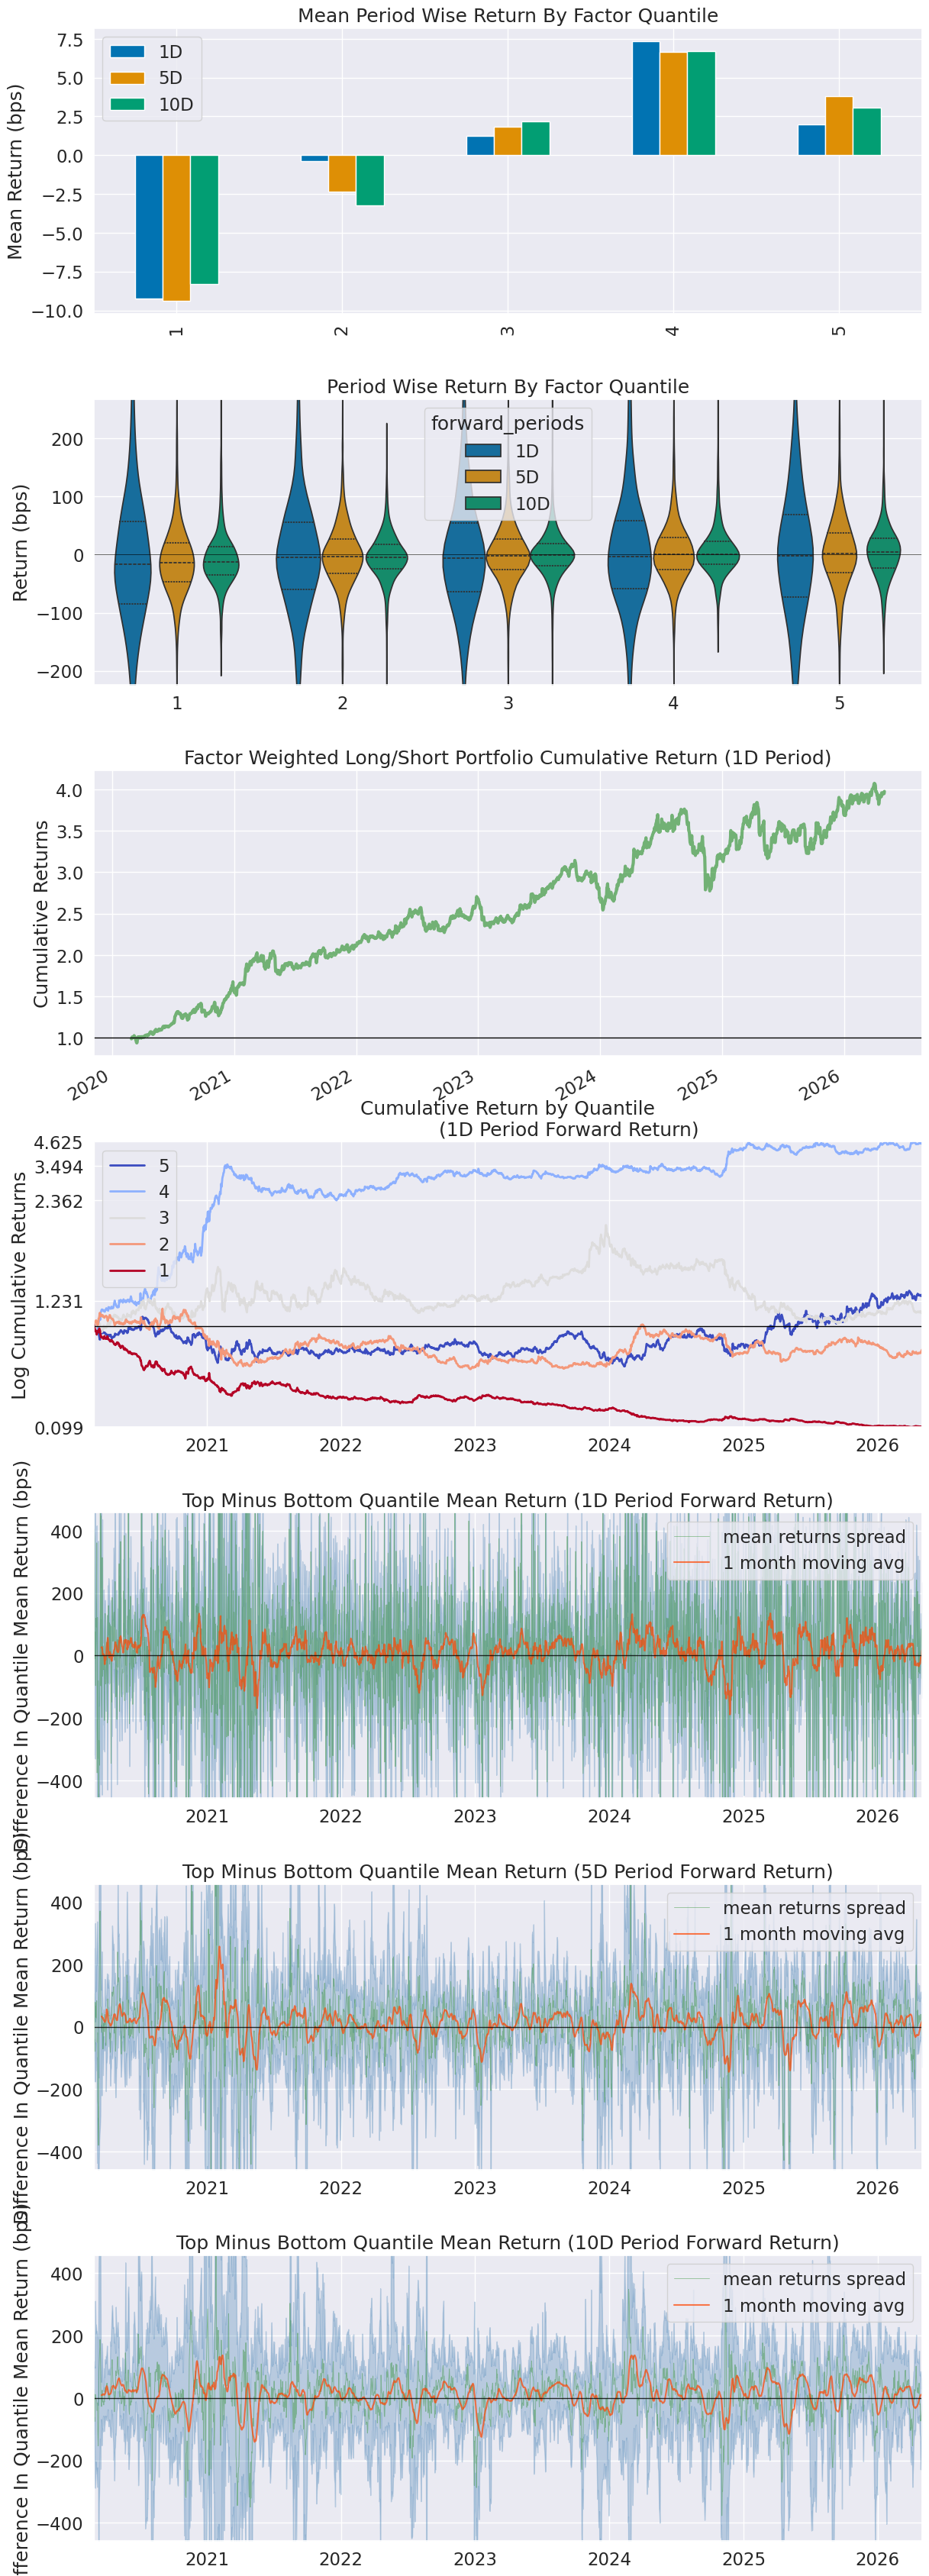

Information Analysis


,1D,5D,10D
IC Mean,0.028,0.049,0.063
IC Std.,0.234,0.236,0.234
Risk-Adjusted IC,0.120,0.209,0.271
t-stat(IC),5.689,9.942,12.868
p-value(IC),0.000,0.000,0.000
IC Skew,0.031,-0.020,-0.115
IC Kurtosis,-0.247,-0.288,-0.245


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


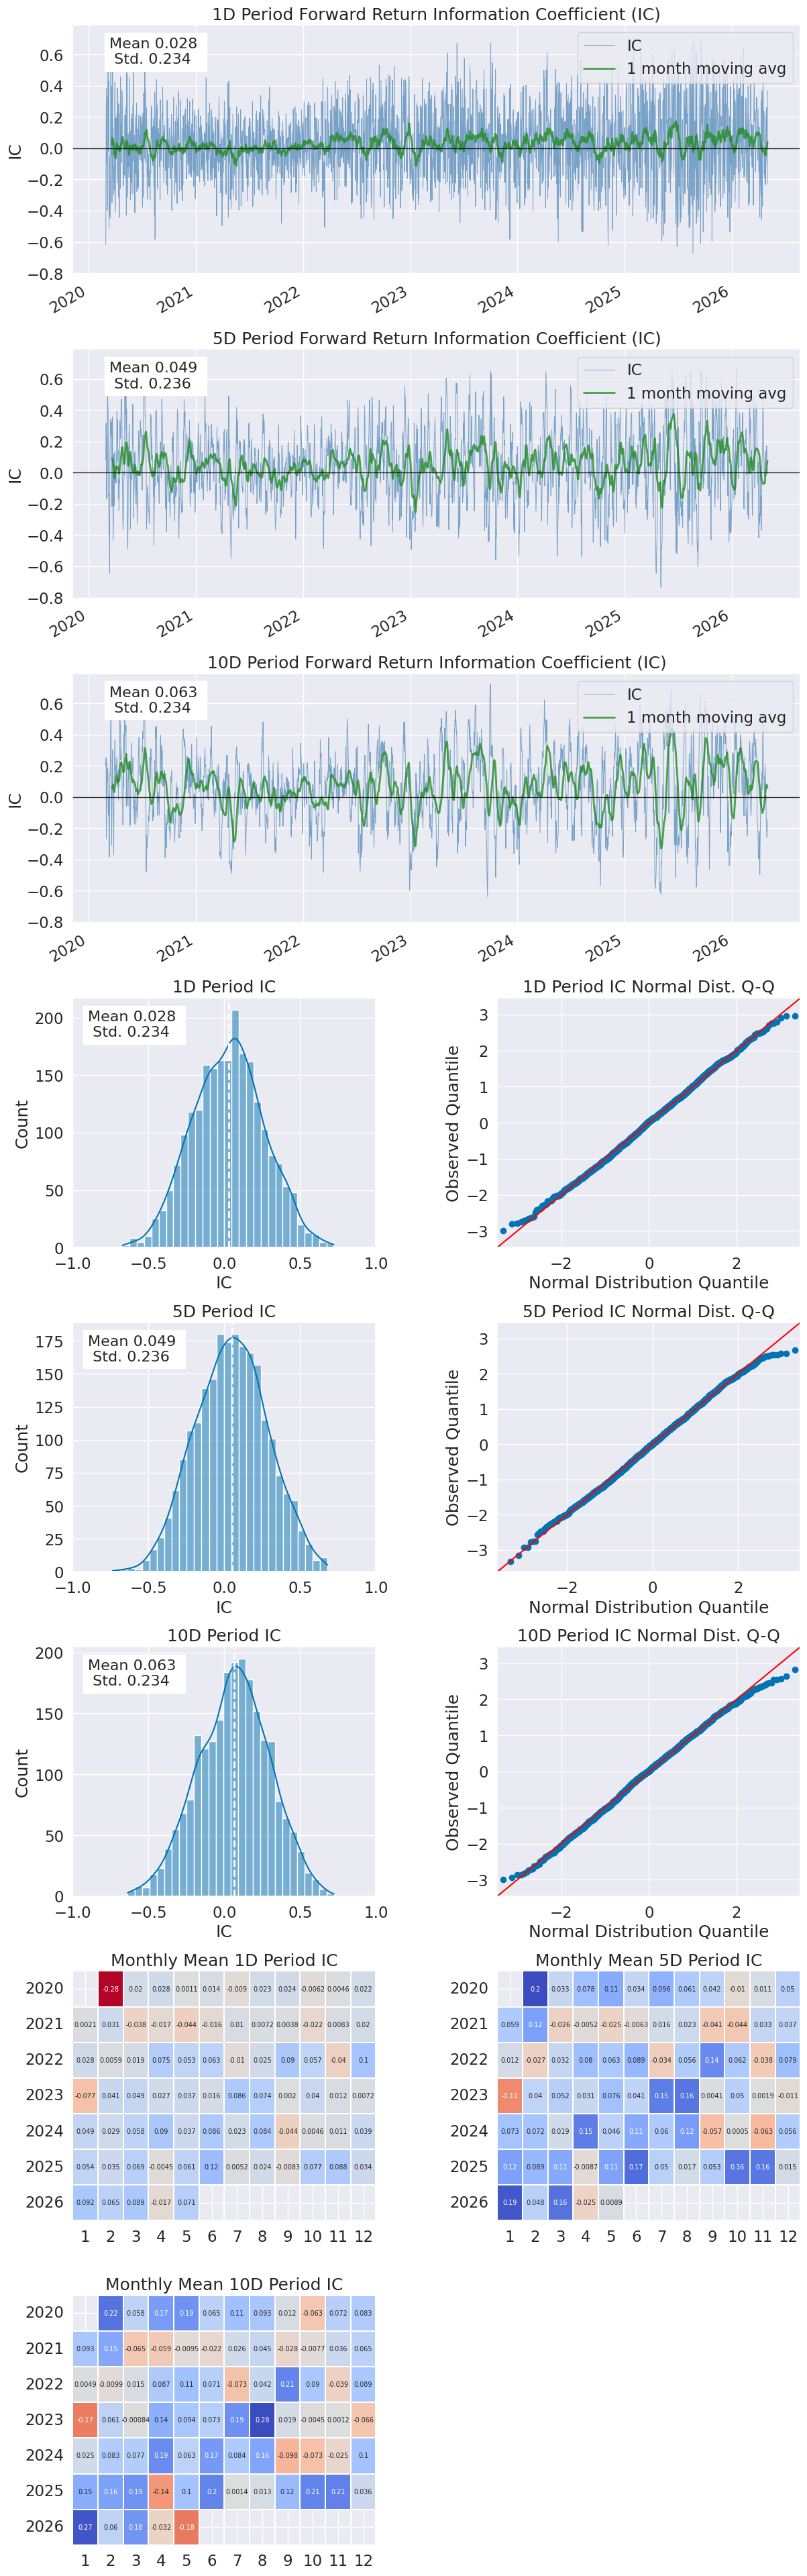

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.095,0.185,0.247
Quantile 2 Mean Turnover,0.160,0.264,0.333
Quantile 3 Mean Turnover,0.170,0.283,0.362
Quantile 4 Mean Turnover,0.130,0.224,0.292
Quantile 5 Mean Turnover,0.063,0.128,0.178


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.991,0.978,0.966


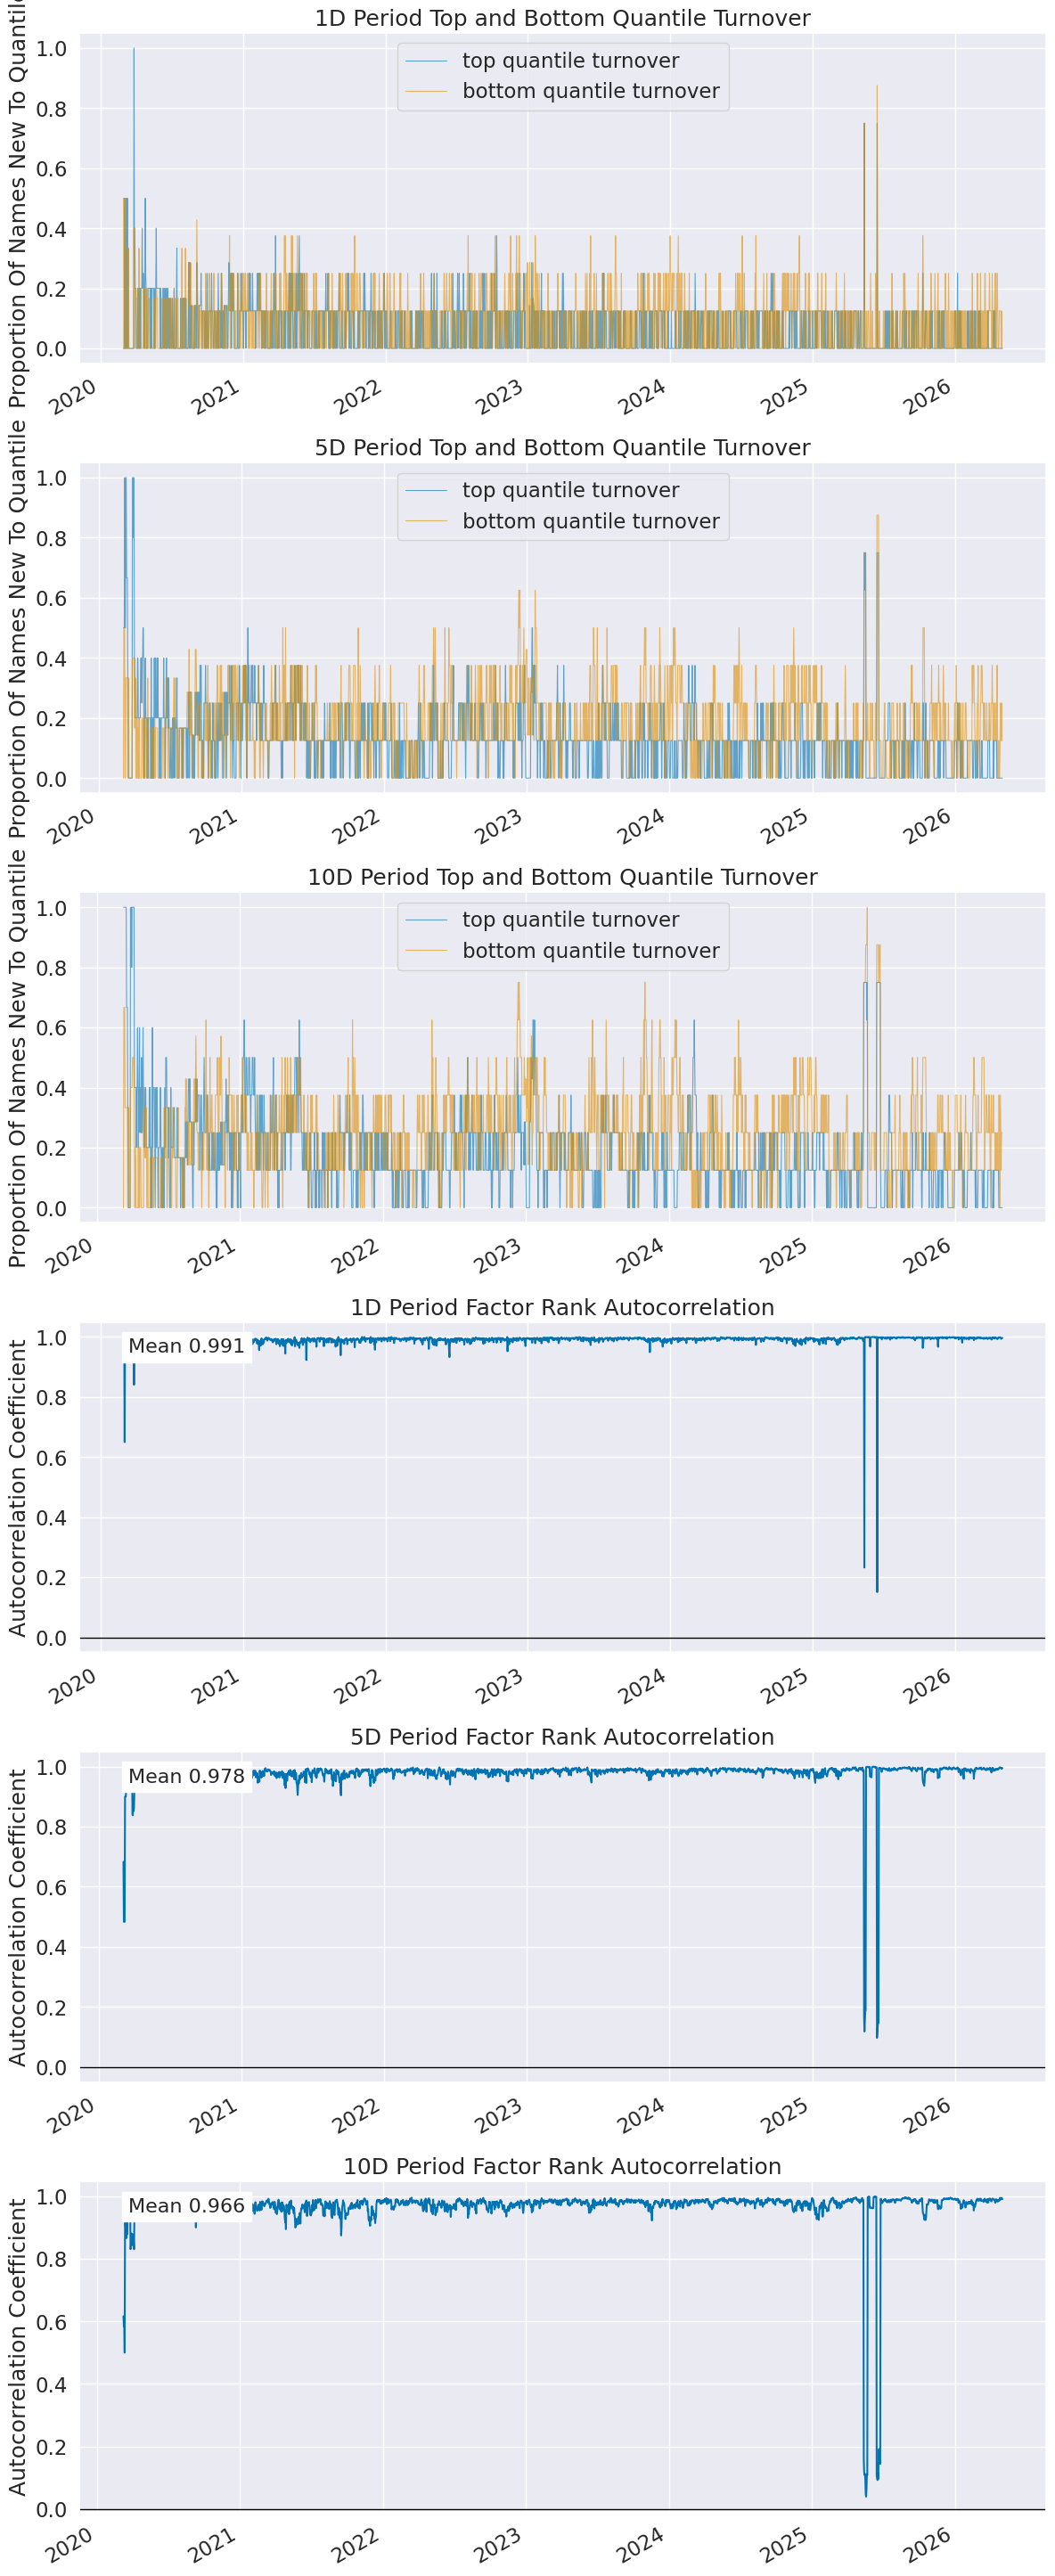

In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "notebooks" / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
for _p in (_root, _root / "notebooks"):
    sys.path.insert(0, str(_p))

from aperiodic import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

APERIODIC_API_KEY = get_env("APERIODIC_API_KEY")

# Open Interest Divergence -- portfolio open_interest_divergence.40
portfolio = "open_interest_divergence"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=APERIODIC_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=APERIODIC_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=APERIODIC_API_KEY)

# Mask the raw factor with the dynamic point-in-time universe (a boolean
# dates x tickers matrix) so AlphaLens scores only the universe we trade,
# not every ticker that was ever tradeable.
universe = get_historical_universe(
    size=universe_size,
    api_key=APERIODIC_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)